# St. Paul Full-Bill LVT Shift — HF 1342

**HF 1342** (and its identical senate companion) authorizes Minnesota cities to create **land-value taxation districts** that reallocate the **entire property tax bill** — city, county, school, areawide, state general levy — among parcels based on land value.

### How it works (Section 4)

The city designates a district. Within that district, **every jurisdiction's levy is still collected in full** — the total tax base doesn't change. But the *allocation among parcels* is shifted: land value carries a higher share, improvements carry a lower share.

### Key difference from city-only analysis (st_paul_v2)

| | st_paul_v2 | This notebook |
|---|---|---|
| Revenue base | City levy (~36% of bill) | **Full tax bill (all jurisdictions)** |
| `current_tax` | `TotalTax1 × 0.3572` | **`TotalTax1`** |
| Modeling approach | TC split-rate, 4:1 | TC split-rate, 4:1 |

Because the full bill is ~2.8× the city portion, the **absolute dollar shifts are larger** and the incentive effect is stronger — the rate advantage per dollar of new improvement is larger under the full-bill model.

In [1]:
# Step 1: Load parcel data
import sys
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from datetime import datetime

sys.path.append('..')

from lvt_utils import (
    ensure_geodataframe, model_split_rate_tax,
    calculate_category_tax_summary, print_category_tax_summary
)
from policy_analysis import (
    analyze_vacant_land, analyze_land_by_improvement_share
)
from census_utils import (
    get_census_data_with_boundaries, match_to_census_blockgroups,
    calculate_median_percentage_by_quintile
)

pd.set_option('display.max_columns', None)

save_dir = os.path.join('data', 'st_paul')

# Find most recent geoparquet
files = [f for f in os.listdir(save_dir) if f.startswith('ramsey_county_') and f.endswith('.gpq')]
files_with_dates = []
for fname in files:
    try:
        date_str = fname.replace('ramsey_county_', '').replace('.gpq', '')
        dt = datetime.strptime(date_str, '%Y%m%d')
        files_with_dates.append((dt, fname))
    except Exception:
        continue

latest_fname = max(files_with_dates, key=lambda x: x[0])[1]
fpath = os.path.join(save_dir, latest_fname)
print(f'Loading: {fpath}')
ramsey_county_gdf = gpd.read_parquet(fpath)
print(f'Loaded {len(ramsey_county_gdf):,} parcels')

Loading: data/st_paul/ramsey_county_20260205.gpq
Loaded 167,677 parcels


## Step 2: Validate Against Official Tax Base

In [2]:
# Load official tax data from MN Dept of Revenue
# Download: https://www.revenue.state.mn.us/property-tax-history-data

excel_path = os.path.join('data', 'st_paul', 'data-portal-excel.xlsx')
city_town_df = pd.read_excel(excel_path, sheet_name='CityTown', header=0)

st_paul_official = city_town_df[
    (city_town_df.iloc[:, 5] == 'ST PAUL CITY OF') & 
    (city_town_df.iloc[:, 1] == 2025)
].iloc[0]

official_data = {
    'Estimated Market Value Total': st_paul_official['Estimated Market Value Total'],
    'Taxable Market Value Total': st_paul_official['Taxable Market Value Total'],
    'Local NTC Total (Tax Capacity)': st_paul_official['Local NTC by Class Total'],
    'TIF NTC': st_paul_official['TIF NTC'],
    'Fiscal Disparities NTC': st_paul_official['Fiscal Disparities Cont NTC'],
    'Taxable NTC': st_paul_official['Taxable NTC'],
    'Net Tax Total': st_paul_official['Net Tax Total'],
    'Total Avg Local NTC Tax Rate': st_paul_official['Total Avg Local NTC Tax Rate'],
    'City/Town Avg Tax Rate': st_paul_official['City/Town Avg Local NTC Tax Rate'],
    'TIF Levy': st_paul_official['TIF Levy'],
}

print('OFFICIAL ST. PAUL 2025 TAX DATA (MN Dept of Revenue)')
for key, val in official_data.items():
    if isinstance(val, float) and val < 10:
        print(f'{key}: {val:.4f}')
    else:
        print(f'{key}: ${val:,.0f}')

# Full combined NTC tax rate (city + county + school + special districts)
OFFICIAL_TOTAL_NTC_RATE = official_data['Total Avg Local NTC Tax Rate']
OFFICIAL_CITY_TAX_RATE = official_data['City/Town Avg Tax Rate']
OFFICIAL_TAXABLE_NTC = official_data['Taxable NTC']
OFFICIAL_TIF_NTC = official_data['TIF NTC']
OFFICIAL_LOCAL_NTC = official_data['Local NTC Total (Tax Capacity)']
OFFICIAL_NET_TAX = official_data['Net Tax Total']

print(f"\nFull combined NTC rate: {OFFICIAL_TOTAL_NTC_RATE:.4f}")
print(f"City-only NTC rate:    {OFFICIAL_CITY_TAX_RATE:.4f}")
print(f"City share of NTC rate: {OFFICIAL_CITY_TAX_RATE / OFFICIAL_TOTAL_NTC_RATE * 100:.1f}%")

OFFICIAL ST. PAUL 2025 TAX DATA (MN Dept of Revenue)
Estimated Market Value Total: $35,832,893,273
Taxable Market Value Total: $34,673,452,267
Local NTC Total (Tax Capacity): $409,200,716
TIF NTC: $28,684,858
Fiscal Disparities NTC: $38,513,418
Taxable NTC: $342,002,440
Net Tax Total: $674,665,907
Total Avg Local NTC Tax Rate: 1.4406
City/Town Avg Tax Rate: 0.5270
TIF Levy: $41,313,536

Full combined NTC rate: 1.4406
City-only NTC rate:    0.5270
City share of NTC rate: 36.6%


## Step 3: Filter to St. Paul City-Taxable Parcels

Under HF 1342, the full tax bill is reallocated. We use `TotalTax1` as the current tax for each parcel.

In [51]:
# Filter to St. Paul parcels
st_paul_gdf = ramsey_county_gdf[ramsey_county_gdf['SiteCityName'] == 'SAINT PAUL'].copy()
print(f'Total St. Paul parcels: {len(st_paul_gdf):,}')

# Flag TIF and exempt parcels
st_paul_gdf['in_tif'] = (
    st_paul_gdf['TIFDistrict'].notna() & 
    (st_paul_gdf['TIFDistrict'].str.strip() != '') &
    (st_paul_gdf['TIFDistrict'] != 'None')
)
st_paul_gdf['fully_exempt'] = (st_paul_gdf['TaxExemptYN'] == 'Y')
st_paul_gdf['pays_city_tax'] = (
    ~st_paul_gdf['in_tif'] & 
    ~st_paul_gdf['fully_exempt'] &
    st_paul_gdf['TaxCapacity'].notna() &
    (st_paul_gdf['TaxCapacity'] > 0)
)

print(f'  In TIF districts:   {st_paul_gdf["in_tif"].sum():,}')
print(f'  Fully tax exempt:   {st_paul_gdf["fully_exempt"].sum():,}')
print(f'  City-taxable:       {st_paul_gdf["pays_city_tax"].sum():,}')

Total St. Paul parcels: 83,399
  In TIF districts:   2,706
  Fully tax exempt:   3,408
  City-taxable:       77,100


In [52]:
# Validate scraped data against official tax base
scraped_total_ntc = st_paul_gdf['TaxCapacity'].sum()
scraped_tif_ntc = st_paul_gdf[st_paul_gdf['in_tif']]['TaxCapacity'].sum()
scraped_city_taxable_ntc = st_paul_gdf[st_paul_gdf['pays_city_tax']]['TaxCapacity'].sum()
scraped_total_emv = st_paul_gdf['EMVTotal1'].sum()

print('VALIDATION: SCRAPED vs OFFICIAL')
print(f"{'Metric':<30} {'Scraped':>18} {'Official':>18} {'Diff %':>10}")
print('-' * 80)

diff_pct = (scraped_total_ntc - OFFICIAL_LOCAL_NTC) / OFFICIAL_LOCAL_NTC * 100
print(f"{'Total Tax Capacity':<30} ${scraped_total_ntc:>15,.0f} ${OFFICIAL_LOCAL_NTC:>15,.0f} {diff_pct:>9.1f}%")

diff_pct = (scraped_tif_ntc - OFFICIAL_TIF_NTC) / OFFICIAL_TIF_NTC * 100
print(f"{'TIF Tax Capacity':<30} ${scraped_tif_ntc:>15,.0f} ${OFFICIAL_TIF_NTC:>15,.0f} {diff_pct:>9.1f}%")

diff_pct = (scraped_city_taxable_ntc - OFFICIAL_TAXABLE_NTC) / OFFICIAL_TAXABLE_NTC * 100
print(f"{'City-Taxable NTC':<30} ${scraped_city_taxable_ntc:>15,.0f} ${OFFICIAL_TAXABLE_NTC:>15,.0f} {diff_pct:>9.1f}%")

diff_pct = (scraped_total_emv - official_data['Estimated Market Value Total']) / official_data['Estimated Market Value Total'] * 100
print(f"{'Total EMV':<30} ${scraped_total_emv:>15,.0f} ${official_data['Estimated Market Value Total']:>15,.0f} {diff_pct:>9.1f}%")

VALIDATION: SCRAPED vs OFFICIAL
Metric                                    Scraped           Official     Diff %
--------------------------------------------------------------------------------
Total Tax Capacity             $    394,941,317 $    409,200,716      -3.5%
TIF Tax Capacity               $     31,367,485 $     28,684,858       9.4%
City-Taxable NTC               $    361,359,418 $    342,002,440       5.7%
Total EMV                      $ 42,268,789,900 $ 35,832,893,273      18.0%


In [53]:
# Create working dataset: city-taxable parcels with FULL tax bill
st_paul_city = st_paul_gdf[st_paul_gdf['pays_city_tax']].copy()

# FULL BILL: current_tax = TotalTax1 (all jurisdictions)
st_paul_city['current_tax'] = st_paul_city['TotalTax1']

current_revenue = st_paul_city['current_tax'].sum()
implied_full_rate = current_revenue / st_paul_city['TaxCapacity'].sum()

print('FULL-BILL TAX BASE')
print(f'Parcels:            {len(st_paul_city):,}')
print(f'Tax Capacity:       ${st_paul_city["TaxCapacity"].sum():,.0f}')
print(f'Total Tax Revenue:  ${current_revenue:,.0f}')
print(f'Official Net Tax:   ${OFFICIAL_NET_TAX:,.0f}')
print(f'Implied full rate:  {implied_full_rate:.4f}')
print(f'Official NTC rate:  {OFFICIAL_TOTAL_NTC_RATE:.4f}')
print(f'\nCompare to city-only: ${current_revenue * 0.3572:,.0f} (city ~35.7% of full bill)')

FULL-BILL TAX BASE
Parcels:            77,100
Tax Capacity:       $361,359,418
Total Tax Revenue:  $559,086,384
Official Net Tax:   $674,665,907
Implied full rate:  1.5472
Official NTC rate:  1.4406

Compare to city-only: $199,705,656 (city ~35.7% of full bill)


## Step 3b: Collapse Condo Units into Buildings

Ramsey County assigns condo units a **token land value** ($1,000 for residential, $500 for garages, $100 for storage). This means the assessor's EMVLand1 for condos is not a real market value — 99.5% of residential condo units show exactly $1,000.

Under the split-rate model, this fake 98.7% improvement ratio would give condos an unearned tax cut. We fix this by:

1. **Collapsing** individual condo units into buildings (grouped by `PlatID`)
2. **Summing** EMVTotal1, TaxCapacity, and TotalTax1 across all units in a building
3. **Imputing** land/building EMV split using the neighborhood's median improvement ratio from non-condo parcels

This gives each condo building a land share that reflects actual neighborhood land values.

In [54]:
from shapely.ops import unary_union
from shapely.geometry import MultiPolygon

condo_mask = st_paul_city['LandUseCodeDescription'].str.contains('CONDO', case=False, na=False)
condos = st_paul_city[condo_mask].copy()
non_condos = st_paul_city[~condo_mask].copy()

print(f'Before collapse: {len(st_paul_city):,} parcels ({len(condos):,} condo units)')
print(f'  Condo EMVLand1:     ${condos["EMVLand1"].sum():>12,.0f}  (token values)')
print(f'  Condo EMVBuilding1: ${condos["EMVBuilding1"].sum():>12,.0f}')
print(f'  Condo EMVTotal1:    ${condos["EMVTotal1"].sum():>12,.0f}')
print(f'  Condo IR: {condos["EMVBuilding1"].sum() / condos["EMVTotal1"].sum() * 100:.1f}%')

def collapse_geometries(geoms):
    geoms = [g for g in geoms if g is not None]
    if not geoms:
        return None
    out = []
    while geoms:
        ref = geoms.pop(0)
        group = [ref]
        rest = []
        for g in geoms:
            if ref.intersects(g) or ref.touches(g) or ref.equals(g):
                group.append(g)
            else:
                rest.append(g)
        unioned = unary_union(group)
        out.append(unioned)
        geoms = rest
    if len(out) == 1:
        return out[0]
    polygons = []
    for g in out:
        if g.geom_type == "Polygon":
            polygons.append(g)
        elif g.geom_type == "MultiPolygon":
            polygons.extend(g.geoms)
        else:
            polygons.append(g)
    return MultiPolygon(polygons)

subset_cols = ['PlatID']
sum_cols = ['EMVLand1', 'EMVBuilding1', 'EMVTotal1', 'TaxCapacity', 'TotalTax1', 'current_tax']
sum_cols = [c for c in sum_cols if c in condos.columns]

# --- Option A: Collapse with "first" for all values (standard dmp approach) ---
# In jurisdictions where the assessor duplicates the full parcel land value on each
# unit, "first" captures the real value. In St. Paul, land values are $1,000 tokens,
# so this loses total EMV and preserves the fake IR.
agg_dict_a = {col: 'first' for col in condos.columns if col not in (subset_cols + ['geometry'])}
agg_dict_a['geometry'] = collapse_geometries
condos_option_a = condos.groupby(subset_cols, dropna=False).agg(agg_dict_a).reset_index()
condos_option_a = gpd.GeoDataFrame(condos_option_a, geometry='geometry', crs=condos.crs)

print(f'\nOption A (first-value collapse):')
print(f'  {len(condos_option_a):,} buildings')
print(f'  EMVLand1:     ${condos_option_a["EMVLand1"].sum():>12,.0f}  (first unit token)')
print(f'  EMVBuilding1: ${condos_option_a["EMVBuilding1"].sum():>12,.0f}')
print(f'  EMVTotal1:    ${condos_option_a["EMVTotal1"].sum():>12,.0f}  (loses ${condos["EMVTotal1"].sum() - condos_option_a["EMVTotal1"].sum():,.0f})')
print(f'  IR: {condos_option_a["EMVBuilding1"].sum() / condos_option_a["EMVTotal1"].sum() * 100:.1f}%')

# --- Option B (used downstream): Collapse with summed values + imputed land/building ---
# Sum financial columns, impute EMVLand1/EMVBuilding1 from neighborhood large
# multi-family median IR (closest structural comp for condo towers)
agg_dict_b = {col: 'first' for col in condos.columns if col not in (subset_cols + ['geometry'])}
for col in sum_cols:
    agg_dict_b[col] = 'sum'
agg_dict_b['geometry'] = collapse_geometries

condos_collapsed = condos.groupby(subset_cols, dropna=False).agg(agg_dict_b).reset_index()
condos_collapsed = gpd.GeoDataFrame(condos_collapsed, geometry='geometry', crs=condos.crs)

# Spatial join non-condos to District Councils for neighborhood IR
dc_dir = os.path.join('data', 'st_paul', 'District_Councils_3386664414246726701')
dc_files = [f for f in os.listdir(dc_dir) if f.endswith('.shp')]
dc_gdf = gpd.read_file(os.path.join(dc_dir, dc_files[0])).to_crs(epsg=3857)
nbhd_col = 'councilnam'

nc_pts = non_condos.to_crs(epsg=3857).copy()
nc_pts['_centroid'] = nc_pts.geometry.centroid
nc_pts_gdf = gpd.GeoDataFrame(nc_pts, geometry='_centroid', crs='EPSG:3857')
nc_joined = gpd.sjoin(nc_pts_gdf, dc_gdf[['geometry', nbhd_col]], how='left', predicate='within')
nc_joined['_ir'] = np.where(nc_joined['EMVTotal1'] > 0, nc_joined['EMVBuilding1'] / nc_joined['EMVTotal1'], 0)

# Use large multi-family IR as the comp for condos
lmf_descs = ['APARTMENTS 7-19', 'APARTMENTS 20-49', 'APARTMENTS 50-99',
             'APT OR COMPLEX 100+', 'ASSISTED LIVING', 'NURSING HOME']
lmf_mask = nc_joined['LandUseCodeDescription'].str.upper().apply(
    lambda d: any(x in d for x in lmf_descs)
)
lmf_parcels = nc_joined[lmf_mask]
neighborhood_lmf_ir = lmf_parcels.groupby(nbhd_col)['_ir'].median()
overall_lmf_ir = lmf_parcels['_ir'].median()

print(f'\nLarge multi-family median IR by neighborhood (comp for condos):')
for name, ir in neighborhood_lmf_ir.sort_values().items():
    print(f'  {name:35s} {ir:.3f}  (land share: {1-ir:.1%})')
print(f'  {"OVERALL":35s} {overall_lmf_ir:.3f}  (land share: {1-overall_lmf_ir:.1%})')

# Join collapsed condos to neighborhoods and impute using large MF IR
condo_pts = condos_collapsed.to_crs(epsg=3857).copy()
condo_pts['_centroid'] = condo_pts.geometry.centroid
condo_pts_gdf = gpd.GeoDataFrame(condo_pts, geometry='_centroid', crs='EPSG:3857')
condo_joined = gpd.sjoin(condo_pts_gdf, dc_gdf[['geometry', nbhd_col]], how='left', predicate='within')
if condo_joined.index.duplicated().any():
    condo_joined = condo_joined[~condo_joined.index.duplicated(keep='first')]

condo_joined['_nbhd_ir'] = condo_joined[nbhd_col].map(neighborhood_lmf_ir).fillna(overall_lmf_ir)
condos_collapsed['EMVLand1'] = (condo_joined['EMVTotal1'] * (1 - condo_joined['_nbhd_ir'])).round(0).values
condos_collapsed['EMVBuilding1'] = (condo_joined['EMVTotal1'] * condo_joined['_nbhd_ir']).round(0).values

print(f'\nOption B (summed values + large MF IR) — used downstream:')
print(f'  {len(condos_collapsed):,} buildings')
print(f'  EMVLand1:     ${condos_collapsed["EMVLand1"].sum():>12,.0f}  (imputed from large MF IR)')
print(f'  EMVBuilding1: ${condos_collapsed["EMVBuilding1"].sum():>12,.0f}')
print(f'  EMVTotal1:    ${condos_collapsed["EMVTotal1"].sum():>12,.0f}  (preserved)')
print(f'  IR: {condos_collapsed["EMVBuilding1"].sum() / condos_collapsed["EMVTotal1"].sum() * 100:.1f}%')

# Reassemble st_paul_city using Option B
st_paul_city = pd.concat([non_condos, condos_collapsed], ignore_index=True)
st_paul_city = gpd.GeoDataFrame(st_paul_city, geometry='geometry', crs=condos.crs)
current_revenue = st_paul_city['current_tax'].sum()

print(f'\nAfter collapse: {len(st_paul_city):,} parcels')
print(f'  Non-condo IR: {non_condos["EMVBuilding1"].sum() / non_condos["EMVTotal1"].sum() * 100:.1f}%')
print(f'  Overall IR:   {st_paul_city["EMVBuilding1"].sum() / st_paul_city["EMVTotal1"].sum() * 100:.1f}%')
print(f'  Total revenue: ${current_revenue:,.0f} (unchanged)')

Before collapse: 77,100 parcels (5,052 condo units)
  Condo EMVLand1:     $  13,042,100  (token values)
  Condo EMVBuilding1: $ 964,998,300
  Condo EMVTotal1:    $ 978,040,400
  Condo IR: 98.7%

Option A (first-value collapse):
  341 buildings
  EMVLand1:     $   2,079,800  (first unit token)
  EMVBuilding1: $ 102,502,700
  EMVTotal1:    $ 104,582,500  (loses $873,457,900)
  IR: 98.0%

Large multi-family median IR by neighborhood (comp for condos):
  Dayton's Bluff Community Council    0.773  (land share: 22.7%)
  Payne-Phalen District 5 Planning Council 0.776  (land share: 22.4%)
  Greater East Side Community Council 0.776  (land share: 22.4%)
  North End Neighborhood Organization 0.782  (land share: 21.8%)
  West Side Community Organization    0.783  (land share: 21.7%)
  Frogtown Neighborhood Association   0.786  (land share: 21.4%)
  Hamline Midway Coalition            0.791  (land share: 20.9%)
  Southeast Community Organization    0.798  (land share: 20.2%)
  District 10 Como Com

## Step 4: Categorize Properties

In [55]:
def categorize_st_paul_property(row):
    desc = str(row.get('LandUseCodeDescription', '')).upper()
    use_type = str(row.get('UseType1', '')).upper()
    emv_building = row.get('EMVBuilding1', 0)

    if 'VACANT' in desc or emv_building == 0:
        if 'RESIDENTIAL' in desc:
            return 'Vacant Residential Land'
        elif 'COMMERCIAL' in desc:
            return 'Vacant Commercial Land'
        elif 'INDUSTRIAL' in desc:
            return 'Vacant Industrial Land'
        else:
            return 'Vacant Other Land'

    if any(x in desc for x in [
        'SINGLE FAMILY', 'TWIN HOME', 'TOWNHOME', 'SINGLE FAMILY W/ACCESSORY'
    ]) or '1A RES' in use_type:
        return 'Single Family Residential'

    if any(x in desc for x in [
        'TWO FAMILY', 'THREE FAMILY', 'FOURPLEX',
        'APARTMENTS 4-6', '2ND RESID 4+ UNITS'
    ]):
        return 'Small Multi-Family (2-4 units)'

    if any(x in desc for x in [
        'APARTMENTS 7-19', 'APARTMENTS 20-49', 'APARTMENTS 50-99',
        'APT OR COMPLEX 100+', 'ASSISTED LIVING', 'NURSING HOME'
    ]):
        return 'Large Multi-Family (5+ units)'

    if 'CONDO' in desc:
        return 'Condominium'

    if 'MIXED' in desc:
        return 'Mixed-Use'

    if any(x in desc for x in [
        'RETAIL', 'STORE', 'SHOP', 'RESTAURANT',
        'HOTEL', 'MOTEL', 'OFFICE', 'BANK',
        'CLINIC', 'THEATER', 'SHOPPING CENTER',
        'SUPERMARKET', 'AUTO DEALER'
    ]):
        return 'Commercial'

    if any(x in desc for x in [
        'INDUSTRIAL', 'WAREHOUSE', 'MANUFACTURING', 'FACTORY',
        'FOUNDERY', 'R&D', 'TRUCK TERMINAL'
    ]):
        return 'Industrial'

    if 'PARKING' in desc:
        return 'Parking'

    if any(x in desc for x in [
        'CHURCH', 'EXEMPT', 'RAILROAD', 'FRATERNITY', 'GOLF COURSE'
    ]):
        return 'Institutional / Special Use'

    return 'Other'

st_paul_city['PROPERTY_CATEGORY'] = st_paul_city.apply(categorize_st_paul_property, axis=1)

# Consolidate vacant categories
vacant_mask = st_paul_city['LandUseCodeDescription'].str.contains('VACANT', case=False, na=False)
st_paul_city.loc[vacant_mask, 'PROPERTY_CATEGORY'] = 'Vacant Land'

print('Property Category Distribution:')
print(st_paul_city['PROPERTY_CATEGORY'].value_counts())

Property Category Distribution:
PROPERTY_CATEGORY
Single Family Residential         59109
Small Multi-Family (2-4 units)     6431
Vacant Land                        2221
Large Multi-Family (5+ units)      1147
Commercial                         1083
Other                               857
Mixed-Use                           551
Industrial                          520
Condominium                         338
Vacant Other Land                   100
Parking                              17
Institutional / Special Use           9
Vacant Residential Land               3
Vacant Industrial Land                2
Vacant Commercial Land                1
Name: count, dtype: int64


## Step 5: Calculate IR, Split Tax Capacity, Run Model

Same TC split-rate approach as v2 but applied to the **full tax bill** instead of just the city's ~36%.

In [56]:
# Calculate Improvement Ratio and split Tax Capacity
st_paul_city['IR'] = st_paul_city['EMVBuilding1'] / st_paul_city['EMVTotal1']
st_paul_city['IR'] = st_paul_city['IR'].fillna(0)

st_paul_city['TaxCapacity_Improvements'] = st_paul_city['IR'] * st_paul_city['TaxCapacity']
st_paul_city['TaxCapacity_Land'] = (1 - st_paul_city['IR']) * st_paul_city['TaxCapacity']

print('Tax Capacity Split Summary:')
print(f'  Total Tax Capacity:          ${st_paul_city["TaxCapacity"].sum():>15,.0f}')
print(f'  Tax Capacity (Improvements): ${st_paul_city["TaxCapacity_Improvements"].sum():>15,.0f}')
print(f'  Tax Capacity (Land):         ${st_paul_city["TaxCapacity_Land"].sum():>15,.0f}')
print(f'  Land % of Tax Capacity:      {st_paul_city["TaxCapacity_Land"].sum() / st_paul_city["TaxCapacity"].sum() * 100:.1f}%')

# Run split-rate model at 4:1 ratio on FULL tax bill
tc_land_improvement_ratio = 4

tc_land_millage, tc_imp_millage, tc_split_rate_revenue, st_paul_city = model_split_rate_tax(
    df=st_paul_city,
    land_value_col='TaxCapacity_Land',
    improvement_value_col='TaxCapacity_Improvements',
    current_revenue=current_revenue,
    land_improvement_ratio=tc_land_improvement_ratio
)

st_paul_city['new_tax_tc'] = st_paul_city['new_tax']
st_paul_city['tax_change_tc'] = st_paul_city['new_tax_tc'] - st_paul_city['current_tax']
st_paul_city['tax_change_pct_tc'] = np.where(
    st_paul_city['current_tax'] > 0,
    (st_paul_city['tax_change_tc'] / st_paul_city['current_tax']) * 100,
    0
)

print(f'\nFull-Bill Split-Rate Model ({tc_land_improvement_ratio}:1 ratio)')
print(f'  Land Millage:        {tc_land_millage:.6f}')
print(f'  Improvement Millage: {tc_imp_millage:.6f}')
print(f'  Current Revenue:     ${current_revenue:,.0f}')
print(f'  New Revenue:         ${st_paul_city["new_tax_tc"].sum():,.0f}')
print(f'  Revenue neutral:     {abs(current_revenue - st_paul_city["new_tax_tc"].sum()) < 1}')

# Undeveloped and underdeveloped land analysis
vacant_results = analyze_vacant_land(
    st_paul_city,
    land_value_col='EMVLand1',
    property_type_col='PROPERTY_CATEGORY',
    vacant_identifier='Vacant Land',
    improvement_value_col='EMVBuilding1'
)
underdeveloped_results = analyze_land_by_improvement_share(
    st_paul_city,
    land_value_col='EMVLand1',
    improvement_value_col='EMVBuilding1'
)

total_land_emv = st_paul_city['EMVLand1'].sum()
print(f'\nUndeveloped and Underdeveloped Land')
print(f'  Total non-exempt land EMV: ${total_land_emv:,.0f}')
print(f'\n  Undeveloped (vacant, IR=0):')
print(f'    {vacant_results["total_vacant_parcels"]:,} parcels')
print(f'    ${vacant_results["total_vacant_land_value"]:,.0f} ({vacant_results["vacant_land_pct_of_total"]:.1f}% of non-exempt land value)')
print(f'\n  Underdeveloped (by improvement share):')
for cat in underdeveloped_results['categories']:
    print(f'    {cat["category"]:35s} {cat["parcel_count"]:>6,} parcels  ${cat["adjusted_land_value"]:>15,.0f}  ({cat["share_of_total_land_value_pct"]:.1f}%)')


Tax Capacity Split Summary:
  Total Tax Capacity:          $    361,359,418
  Tax Capacity (Improvements): $    281,207,636
  Tax Capacity (Land):         $     80,151,782
  Land % of Tax Capacity:      22.2%
Split-rate tax model (Land:Improvement = 4:1)
Land millage rate: 3716.0031
Improvement millage rate: 929.0008
Total tax revenue: $559,086,383.56
Target revenue: $559,086,383.56
Revenue difference: $-0.00 (-0.0000%)

Full-Bill Split-Rate Model (4:1 ratio)
  Land Millage:        3716.003108
  Improvement Millage: 929.000777
  Current Revenue:     $559,086,384
  New Revenue:         $559,086,384
  Revenue neutral:     True

Undeveloped and Underdeveloped Land
  Total non-exempt land EMV: $6,454,110,723

  Undeveloped (vacant, IR=0):
    2,221 parcels
    $199,800,511 (3.1% of non-exempt land value)

  Underdeveloped (by improvement share):
    0% improvement                       2,256 parcels  $    221,716,600  (3.4%)
    <10% improvement (excl. 0%)             27 parcels  $     25,

## Step 6: Category Summary & Charts

In [57]:
# Tax impact summary by property category
st_paul_city['abs_tax_diff'] = (st_paul_city['current_tax'] - st_paul_city['new_tax_tc']).abs()
total_abs_tax_diff = st_paul_city['abs_tax_diff'].sum()
percent_of_current = (total_abs_tax_diff / current_revenue) * 100
print(f'Sum of absolute tax difference: ${total_abs_tax_diff:,.2f}')
print(f'That is {percent_of_current:.2f}% of current full tax revenue.\n')

output_summary = calculate_category_tax_summary(
    st_paul_city,
    category_col='PROPERTY_CATEGORY',
    current_tax_col='current_tax',
    new_tax_col='new_tax_tc'
)
print_category_tax_summary(output_summary, 'Full-Bill Split-Rate Impact by Property Category')

Sum of absolute tax difference: $128,932,251.78
That is 23.06% of current full tax revenue.


Full-Bill Split-Rate Impact by Property Category
                      Category  Count Total Tax Change ($) Total Change (%) Mean Change ($) Median Change ($) Avg % Change Median % Change % Parcels > +10% % Parcels < -10%
     Single Family Residential  59012           $5,948,897             2.2%            $101             $-356        -3.3%          -10.1%            23.9%            50.2%
Small Multi-Family (2-4 units)   6427          $-2,593,837            -6.7%           $-404             $-628        -9.2%          -14.1%            15.4%            60.8%
                   Vacant Land   2152           $7,246,352           128.6%          $3,367              $981       161.6%          152.0%            95.1%             1.4%
 Large Multi-Family (5+ units)   1146         $-16,624,089           -20.0%        $-14,506           $-4,015       -17.3%          -12.7%             5.7%          

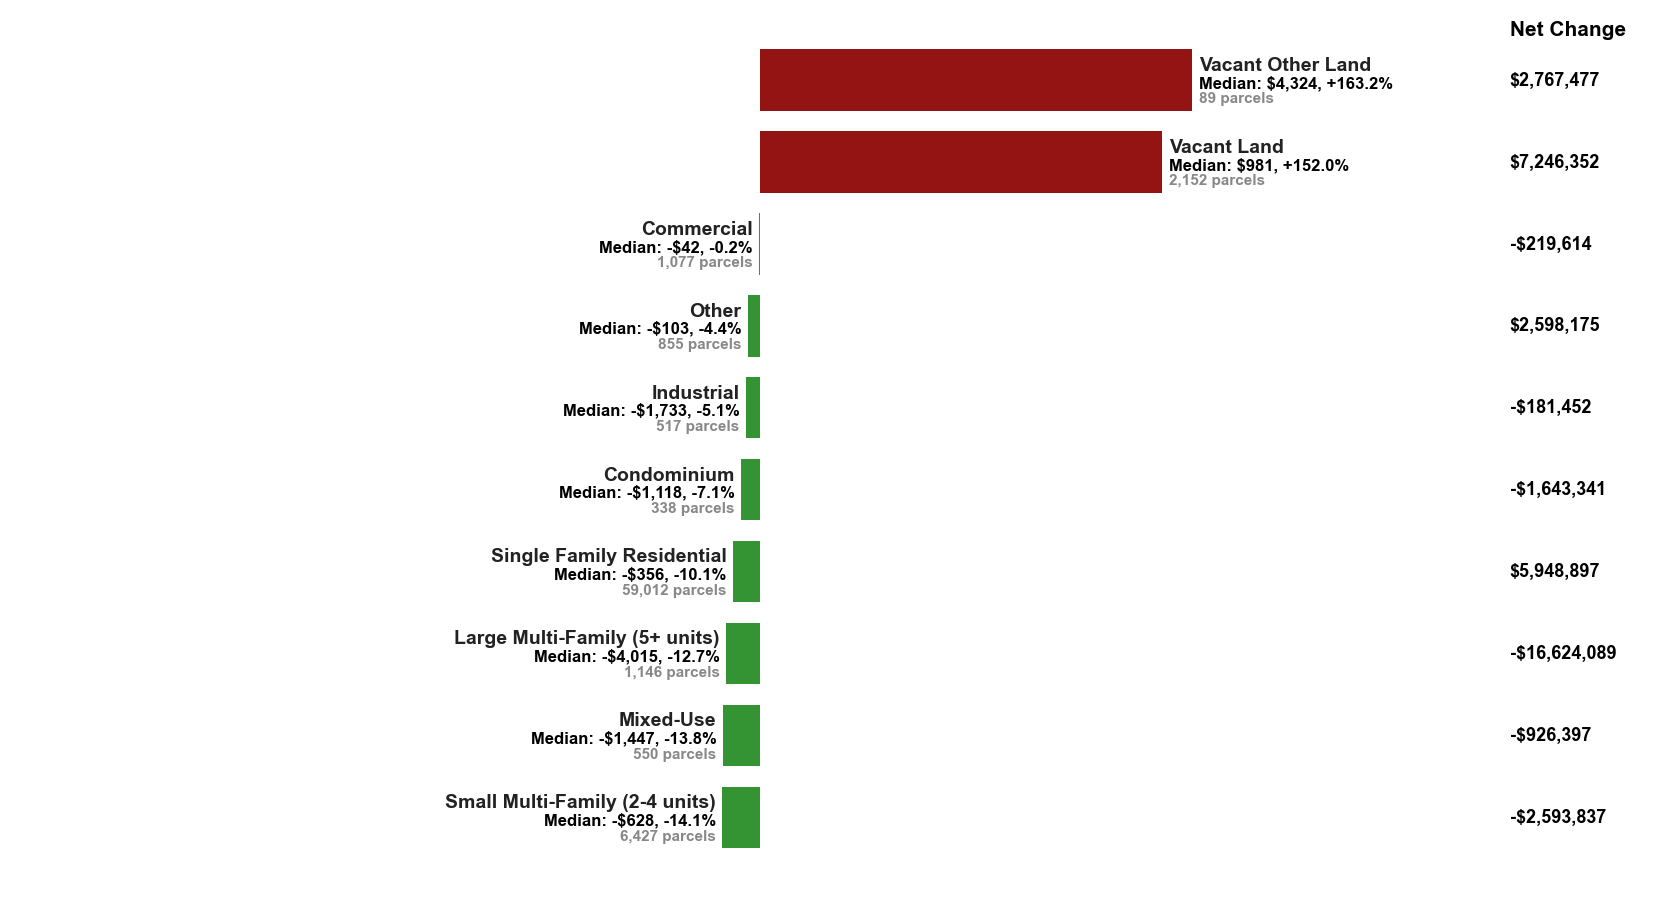

In [58]:
# Horizontal bar chart: median % change by category
import matplotlib.pyplot as plt

filtered = output_summary[output_summary['property_count'] > 50].copy()

categories = filtered['PROPERTY_CATEGORY'].tolist()
counts = filtered['property_count'].tolist()
median_pct_change = filtered['median_tax_change_pct'].tolist()
median_dollar_change = filtered['median_tax_change'].tolist()
total_tax_change = filtered['total_tax_change'].tolist() if 'total_tax_change' in filtered.columns else (filtered['mean_tax_change'] * filtered['property_count']).tolist()

sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

bar_colors = ['#8B0000' if val > 0 else '#228B22' for val in median_pct_change]

bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120
fig, ax = plt.subplots(figsize=(17, fig_height))

y = np.arange(len(categories))

ax.barh(y, median_pct_change, color=bar_colors, edgecolor='none',
        height=bar_height, alpha=0.92, linewidth=0, zorder=2)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

cat_offset = 0.18
med_offset = -0.03
count_offset = -0.23

max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad

ax.text(right_col_x, len(categories) - 0.5, 'Net Change', va='bottom', ha='left',
        fontsize=15, fontweight='bold', color='black', fontname='Arial')

for i, (cat, val, count, med_dol, tot_change) in enumerate(
    zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)):
    med_dol_str = f'${med_dol:,.0f}' if med_dol >= 0 else f'-${abs(med_dol):,.0f}'
    pct_str = f'{val:+.1f}%'
    median_combo = f'Median: {med_dol_str}, {pct_str}'

    xpos = val - 2.5 if val < 0 else val + 2.5
    ha = 'right' if val < 0 else 'left'

    ax.text(xpos, y[i]+cat_offset, cat, va='center', ha=ha,
            fontsize=14, fontweight='bold', color='#222', fontname='Arial')
    ax.text(xpos, y[i]+med_offset, median_combo, va='center', ha=ha,
            fontsize=12, fontweight='bold', color='black', fontname='Arial')
    ax.text(xpos, y[i]+count_offset, f'{count:,} parcels', va='center', ha=ha,
            fontsize=11, fontweight='bold', color='#888', fontname='Arial')

    tot_change_str = f'${tot_change:,.0f}' if tot_change >= 0 else f'-${abs(tot_change):,.0f}'
    ax.text(right_col_x, y[i], tot_change_str, va='center', ha='left',
            fontsize=13, fontweight='bold', color='black', fontname='Arial')

ax.set_xlim(-right_col_x, right_col_x + 60)
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.show()

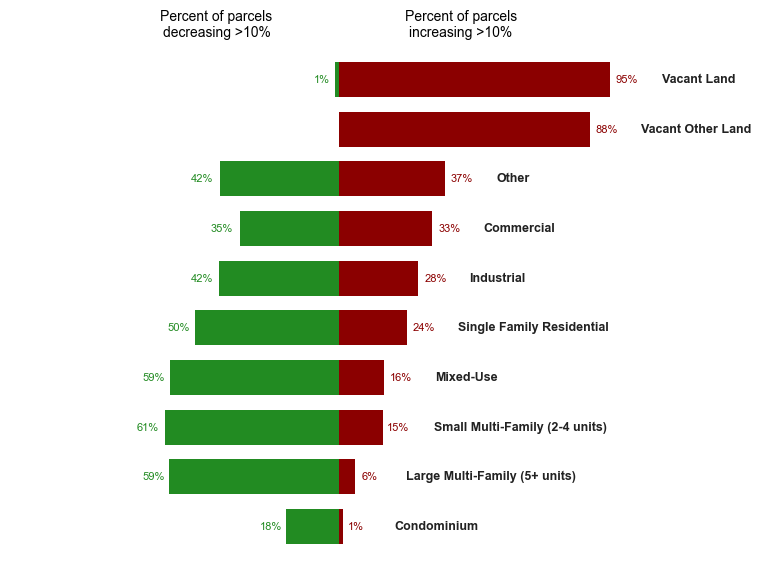

In [59]:
# Butterfly chart: percent of parcels increasing/decreasing >10%
import matplotlib.pyplot as plt

summary_filtered = output_summary[output_summary['property_count'] > 50].copy()
summary_sorted = summary_filtered.sort_values('pct_increase_gt_threshold', ascending=True)

categories_sorted = summary_sorted['PROPERTY_CATEGORY'].tolist()
pct_increase_sorted = summary_sorted['pct_increase_gt_threshold'].tolist()
pct_decrease_sorted = summary_sorted['pct_decrease_gt_threshold'].tolist()

pct_increase_int = [int(round(x)) for x in pct_increase_sorted]
pct_decrease_int = [int(round(x)) for x in pct_decrease_sorted]

y = np.arange(len(categories_sorted))
fig, ax = plt.subplots(figsize=(8, 6))

color_increase = '#8B0000'
color_decrease = '#228B22'

ax.barh(y, [-v for v in pct_decrease_sorted], color=color_decrease, edgecolor='none', height=0.7)
ax.barh(y, pct_increase_sorted, color=color_increase, edgecolor='none', height=0.7)

for i, (inc, dec) in enumerate(zip(pct_increase_int, pct_decrease_int)):
    if dec > 0:
        ax.text(-dec - 2, y[i], f'{dec}%', va='center', ha='right',
                fontsize=8, color=color_decrease, fontname='Arial')
    if inc > 0:
        ax.text(inc + 2, y[i], f'{inc}%', va='center', ha='left',
                fontsize=8, color=color_increase, fontname='Arial')

for i, (cat, inc) in enumerate(zip(categories_sorted, pct_increase_sorted)):
    xpos = inc + 18 if inc > 0 else 18
    ax.text(xpos, y[i], cat, va='center', ha='left',
            fontsize=9, fontweight='bold', color='#222', fontname='Arial')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_yticks([])
ax.set_xticks([])

max_val = max(max(pct_increase_sorted), max(pct_decrease_sorted))
ax.set_xlim(-max_val-20, max_val+48)

title_y = len(categories_sorted) - 0.2
ax.text(-max_val * 0.45, title_y, 'Percent of parcels\ndecreasing >10%',
        ha='center', va='bottom', fontsize=10, color='black', fontname='Arial',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))
ax.text(max_val * 0.45, title_y, 'Percent of parcels\nincreasing >10%',
        ha='center', va='bottom', fontsize=10, color='black', fontname='Arial',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))

plt.tight_layout()
plt.show()

## Step 7: Scatter Plots

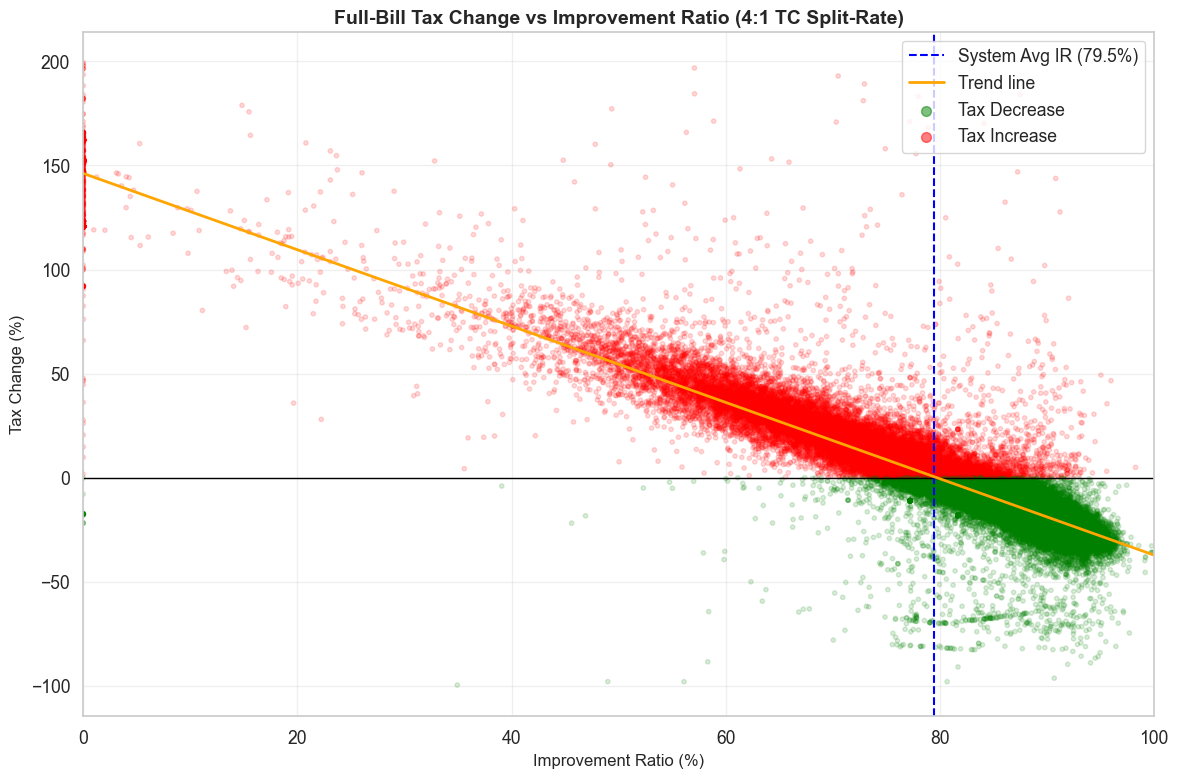


Plot shows 71,453 parcels
  Green (tax decrease): 47,288
  Red (tax increase): 24,165


In [60]:
# Scatter plot: Tax Change vs Improvement Ratio (full bill)
import matplotlib.pyplot as plt

# Use st_paul_city which already has the model results
plot_data = st_paul_city[
    (st_paul_city['current_tax'] > 100) & 
    (st_paul_city['IR'].notna()) &
    (st_paul_city['tax_change_pct_tc'].between(-100, 200))
].copy()

fig, ax = plt.subplots(figsize=(12, 8))

colors = np.where(plot_data['tax_change_pct_tc'] < 0, 'green', 'red')

ax.scatter(
    plot_data['IR'] * 100,
    plot_data['tax_change_pct_tc'],
    alpha=0.15, s=10, c=colors
)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

system_avg_ir = (st_paul_city['EMVBuilding1'].sum() / st_paul_city['EMVTotal1'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5,
           label=f'System Avg IR ({system_avg_ir:.1f}%)')

z = np.polyfit(plot_data['IR'] * 100, plot_data['tax_change_pct_tc'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, p(x_line), 'orange', linewidth=2, label='Trend line')

ax.scatter([], [], c='green', alpha=0.5, s=50, label='Tax Decrease')
ax.scatter([], [], c='red', alpha=0.5, s=50, label='Tax Increase')

ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Full-Bill Tax Change vs Improvement Ratio ({tc_land_improvement_ratio}:1 TC Split-Rate)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

print(f'\nPlot shows {len(plot_data):,} parcels')
print(f'  Green (tax decrease): {(plot_data["tax_change_pct_tc"] < 0).sum():,}')
print(f'  Red (tax increase): {(plot_data["tax_change_pct_tc"] >= 0).sum():,}')

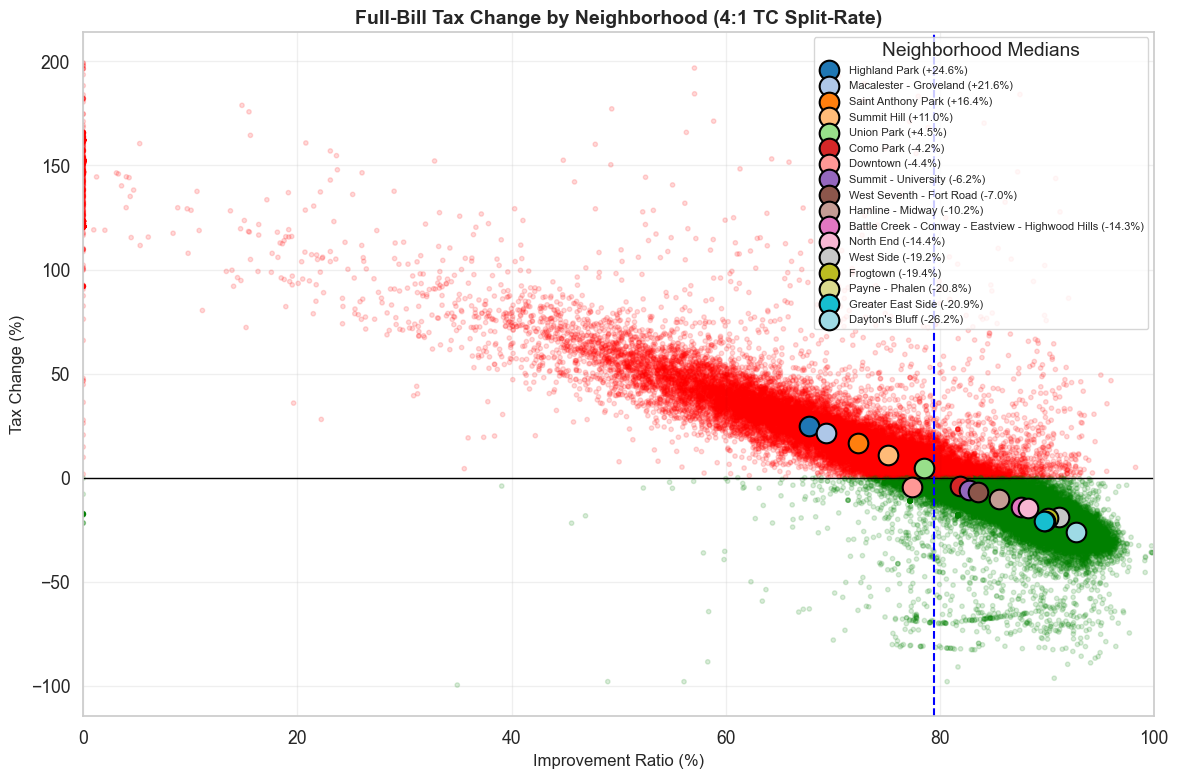


Plot shows 71,453 parcels across 17 neighborhoods


In [61]:
# Scatter plot: Tax Change by Neighborhood (full bill)
import matplotlib.pyplot as plt

# Spatial join to District Council neighborhoods
neighborhoods = gpd.read_file('data/st_paul/District_Councils_3386664414246726701')
neighborhoods = neighborhoods[['planning_1', 'geometry']].rename(columns={'planning_1': 'Neighborhood'})
neighborhoods = neighborhoods.to_crs(epsg=3857)

plot_source_3857 = st_paul_city.to_crs(epsg=3857)
plot_source_3857['centroid'] = plot_source_3857.geometry.centroid
centroids = gpd.GeoDataFrame(
    plot_source_3857.drop(columns='geometry'), geometry='centroid', crs='EPSG:3857'
)
plot_with_nbhd = gpd.sjoin(centroids, neighborhoods, how='left', predicate='within')
plot_with_nbhd = plot_with_nbhd.drop(columns=['index_right', 'centroid'])

plot_data = plot_with_nbhd[
    (plot_with_nbhd['current_tax'] > 100) & 
    (plot_with_nbhd['Neighborhood'].notna()) &
    (plot_with_nbhd['tax_change_pct_tc'].between(-100, 200))
].copy()

fig, ax = plt.subplots(figsize=(12, 8))

colors = np.where(plot_data['tax_change_pct_tc'] < 0, 'green', 'red')
ax.scatter(plot_data['IR'] * 100, plot_data['tax_change_pct_tc'],
           alpha=0.15, s=10, c=colors)

# Neighborhood medians
neighborhood_stats = plot_data.groupby('Neighborhood').agg({
    'IR': 'median',
    'tax_change_pct_tc': 'median',
    'TaxCapacity': 'count'
}).reset_index()
neighborhood_stats.columns = ['Neighborhood', 'median_IR', 'median_tax_change', 'count']
neighborhood_stats = neighborhood_stats.sort_values('median_tax_change', ascending=False)

cmap_colors = plt.cm.tab20(np.linspace(0, 1, len(neighborhood_stats)))
for i, row in enumerate(neighborhood_stats.itertuples()):
    ax.scatter(
        row.median_IR * 100, row.median_tax_change,
        s=200, c=[cmap_colors[i]], edgecolors='black', linewidths=1.5,
        label=f'{row.Neighborhood} ({row.median_tax_change:+.1f}%)', zorder=5
    )

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
system_avg_ir = (st_paul_city['EMVBuilding1'].sum() / st_paul_city['EMVTotal1'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5)

ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Full-Bill Tax Change by Neighborhood ({tc_land_improvement_ratio}:1 TC Split-Rate)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, title='Neighborhood Medians')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

print(f'\nPlot shows {len(plot_data):,} parcels across {plot_data["Neighborhood"].nunique()} neighborhoods')

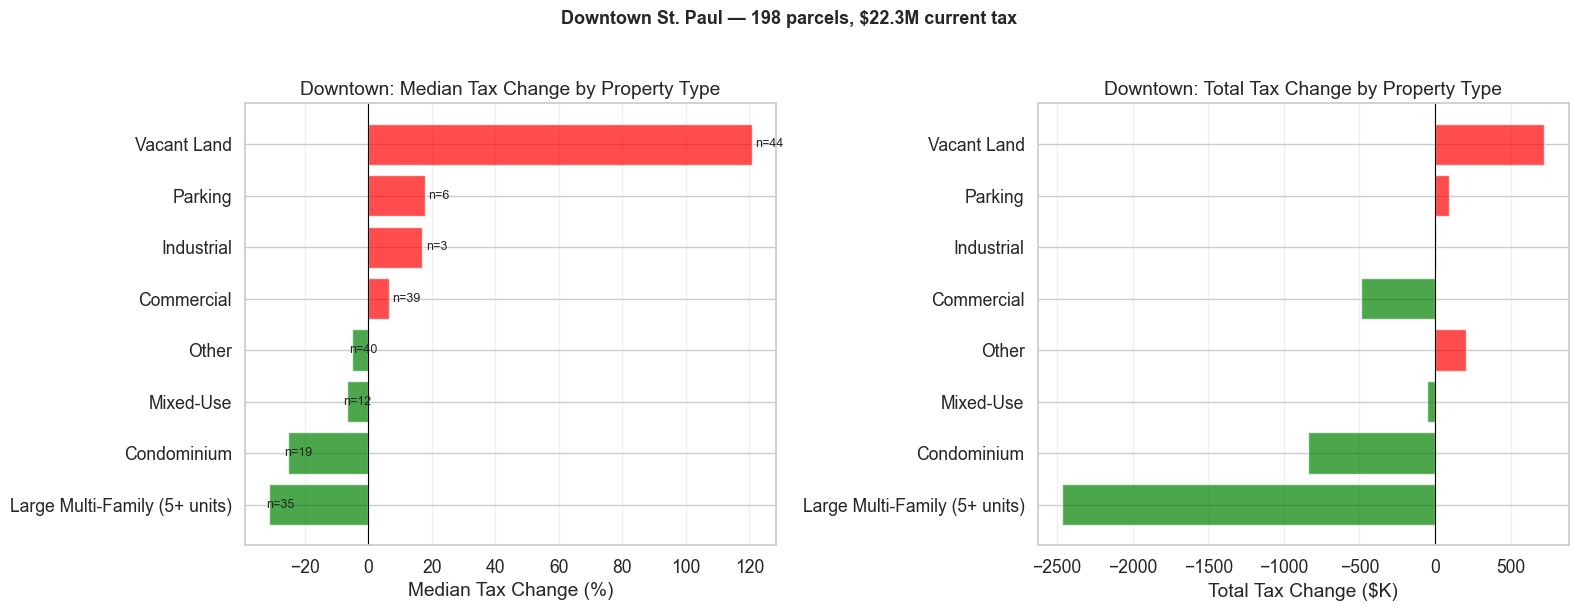


Downtown summary:
  Large Multi-Family (5+ units)       n=  35  median:  -31.3%  total: $  -2,467,160
  Condominium                         n=  19  median:  -25.4%  total: $    -837,102
  Mixed-Use                           n=  12  median:   -6.9%  total: $     -53,698
  Other                               n=  40  median:   -5.2%  total: $    +208,128
  Commercial                          n=  39  median:   +6.4%  total: $    -488,636
  Industrial                          n=   3  median:  +17.0%  total: $      +5,423
  Parking                             n=   6  median:  +17.9%  total: $     +93,354
  Vacant Land                         n=  44  median: +120.7%  total: $    +724,692


In [62]:
# Downtown tax change by property category
import matplotlib.pyplot as plt
import numpy as np

downtown = plot_with_nbhd[plot_with_nbhd['Neighborhood'] == 'Downtown'].copy()

dt_summary = downtown.groupby('PROPERTY_CATEGORY').agg(
    count=('tax_change_pct_tc', 'size'),
    median_change=('tax_change_pct_tc', 'median'),
    total_current=('current_tax', 'sum'),
    total_new=('new_tax_tc', 'sum')
).reset_index()
dt_summary['total_change'] = dt_summary['total_new'] - dt_summary['total_current']
dt_summary = dt_summary.sort_values('median_change')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: median % change by category
colors = ['green' if x < 0 else 'red' for x in dt_summary['median_change']]
bars = ax1.barh(dt_summary['PROPERTY_CATEGORY'], dt_summary['median_change'], color=colors, alpha=0.7)
for bar, count in zip(bars, dt_summary['count']):
    x = bar.get_width()
    ax1.text(x + (1 if x >= 0 else -1), bar.get_y() + bar.get_height()/2,
             f'n={count}', va='center', fontsize=9)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlabel('Median Tax Change (%)')
ax1.set_title('Downtown: Median Tax Change by Property Type')
ax1.grid(True, alpha=0.3, axis='x')

# Right: total dollar change by category
colors2 = ['green' if x < 0 else 'red' for x in dt_summary['total_change']]
ax2.barh(dt_summary['PROPERTY_CATEGORY'], dt_summary['total_change'] / 1000, color=colors2, alpha=0.7)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Total Tax Change ($K)')
ax2.set_title('Downtown: Total Tax Change by Property Type')
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Downtown St. Paul — {len(downtown):,} parcels, ${downtown["current_tax"].sum()/1e6:.1f}M current tax',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nDowntown summary:")
for _, row in dt_summary.iterrows():
    print(f"  {row['PROPERTY_CATEGORY']:35s} n={row['count']:>4}  median: {row['median_change']:>+6.1f}%  total: ${row['total_change']:>+12,.0f}")

## Step 8: Census Equity Analysis

In [63]:
# Get census data for Ramsey County
census_data, census_boundaries = get_census_data_with_boundaries(
    fips_code='27123',
    year=2022
)

census_boundaries = census_boundaries.set_crs(epsg=4326)
boundary_gdf = st_paul_city.to_crs(epsg=4326)

df = match_to_census_blockgroups(
    gdf=boundary_gdf,
    census_gdf=census_boundaries,
    join_type='left'
)

print(f'Census block groups: {len(census_boundaries)}')
print(f'Parcels with census data: {len(df)}')

Census block groups: 7753
Parcels with census data: 72389


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

def filter_data(df):
    df_filtered = df[df['median_income'] > 0].copy()
    non_vacant_df = df[(df['PROPERTY_CATEGORY'] != 'Vacant Land') & (df['median_income'] > 0)].copy()
    return df_filtered, non_vacant_df

def calculate_block_group_summary(df):
    df = df[df['median_income'] > 0].copy()
    summary = df.groupby('std_geoid').agg(
        median_income=('median_income', 'first'),
        minority_pct=('minority_pct', 'first'),
        black_pct=('black_pct', 'first'),
        total_current_tax=('current_tax', 'sum'),
        total_new_tax=('new_tax_tc', 'sum'),
        mean_tax_change=('tax_change_tc', 'mean'),
        median_tax_change=('tax_change_tc', 'median'),
        median_tax_change_pct=('tax_change_pct_tc', 'median'),
        parcel_count=('tax_change_tc', 'count'),
        has_vacant_land=('PROPERTY_CATEGORY', lambda x: 'Vacant Land' in x.values)
    ).reset_index()
    summary = summary[summary['median_income'] > 0].copy()
    summary['mean_tax_change_pct'] = ((summary['total_new_tax'] - summary['total_current_tax']) / 
                                    summary['total_current_tax']) * 100
    return summary

def weighted_median(values, weights):
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = np.array(values)[mask]
    weights = np.array(weights)[mask]
    if len(values) == 0:
        return np.nan
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cumsum = np.cumsum(weights)
    cutoff = weights.sum() / 2.0
    return values[np.searchsorted(cumsum, cutoff)]

def create_quintile_summary(df, group_col, value_col):
    if group_col == 'median_income':
        df = df[df['median_income'] > 0].copy()
    df[f'{group_col}_quintile'] = pd.qcut(df[group_col], 5,
                                         labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])
    summary = df.groupby(f'{group_col}_quintile').apply(
        lambda g: pd.Series({
            'count': g['tax_change_tc'].count(),
            'mean_tax_change_pct': g['tax_change_pct_tc'].mean(),
            'median_tax_change_pct': weighted_median(g['tax_change_pct_tc'].values, np.ones(len(g))),
            'mean_value': g[value_col].mean()
        })
    ).reset_index()
    return summary

# Run analysis
gdf_filtered, non_vacant_gdf = filter_data(df)
print(f'Filtered parcels: {len(gdf_filtered):,}')
print(f'Non-vacant parcels: {len(non_vacant_gdf):,}')

income_quintile_summary = create_quintile_summary(gdf_filtered, 'median_income', 'median_income')
non_vacant_income_quintile_summary = create_quintile_summary(non_vacant_gdf, 'median_income', 'median_income')
minority_quintile_summary = create_quintile_summary(gdf_filtered, 'minority_pct', 'minority_pct')
non_vacant_minority_quintile_summary = create_quintile_summary(non_vacant_gdf, 'minority_pct', 'minority_pct')

print('\nTax impact by income quintile (all properties):')
display(income_quintile_summary)
print('\nTax impact by income quintile (excluding vacant land):')
display(non_vacant_income_quintile_summary)
print('\nTax impact by minority % quintile (all properties):')
display(minority_quintile_summary)
print('\nTax impact by minority % quintile (excluding vacant land):')
display(non_vacant_minority_quintile_summary)

Filtered parcels: 70,115
Non-vacant parcels: 68,004


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and wil


Tax impact by income quintile (all properties):


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the groupin

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),14227.0,4.434299,-14.600722,44538.937088
1,Q2,13943.0,0.162700,-14.354386,64110.917543
2,Q3,13888.0,-5.469096,-14.138350,79714.596075
3,Q4,13868.0,-0.373057,-9.154311,98276.290115
4,Q5 (Highest),13997.0,15.120214,12.426198,135254.166465


...

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),13602.0,-5.985859,-15.435293,44797.660401
1,Q2,13860.0,-6.726923,-15.703718,64641.744201
2,Q3,13308.0,-9.296348,-14.331319,80308.368994
3,Q4,13608.0,-3.249503,-9.652570,98936.101844
4,Q5 (Highest),13503.0,14.736319,12.877599,135903.759748



Tax impact by minority % quintile (all properties):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),14121.0,16.048136,10.916611,9.036987
1,Q2,13913.0,10.606896,4.127362,20.563233
2,Q3,14281.0,-2.564800,-12.002221,39.846771
3,Q4,13772.0,-7.704424,-19.302298,63.937303
4,Q5 (Highest),13836.0,-2.519804,-18.720734,80.088836



Tax impact by minority % quintile (excluding vacant land):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),13624.0,13.847295,10.029849,8.929531
1,Q2,13963.0,8.642495,4.075013,20.404741
2,Q3,13490.0,-6.745102,-12.109050,39.562034
3,Q4,13426.0,-15.136019,-19.890279,63.547641
4,Q5 (Highest),13378.0,-11.812780,-19.196093,79.904061


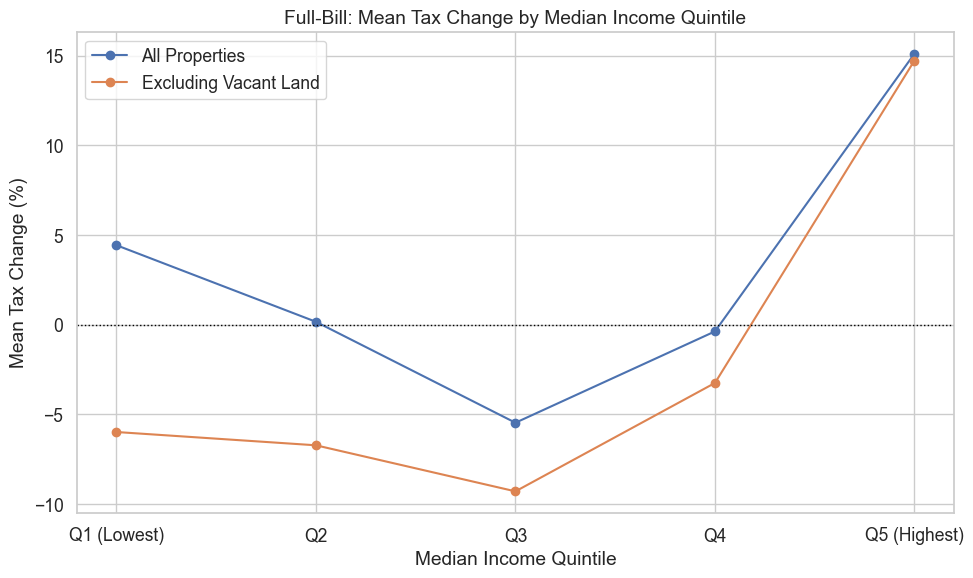

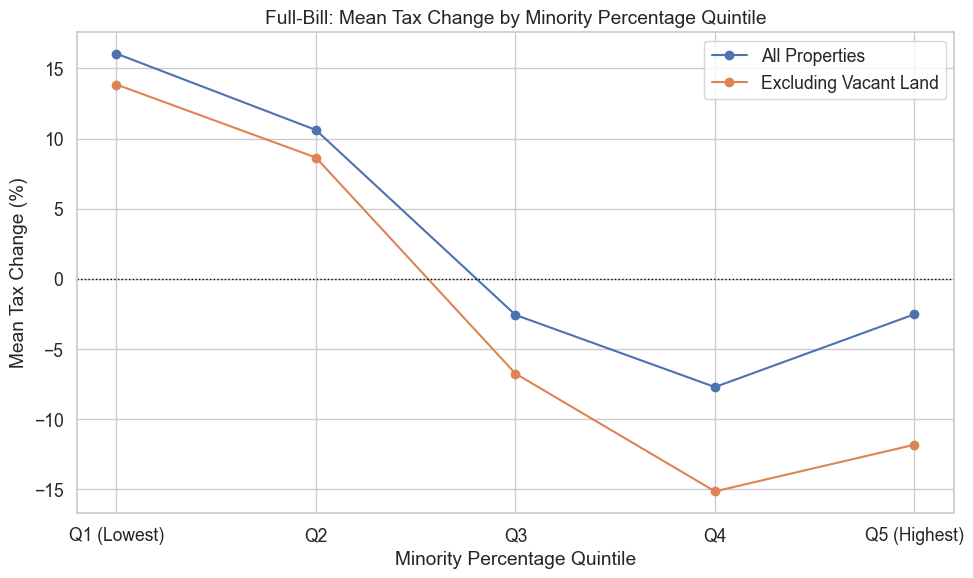

In [65]:
# Quintile line plots
plt.figure(figsize=(10, 6))
plt.plot(income_quintile_summary['median_income_quintile'],
         income_quintile_summary['mean_tax_change_pct'], marker='o', label='All Properties')
plt.plot(non_vacant_income_quintile_summary['median_income_quintile'],
         non_vacant_income_quintile_summary['mean_tax_change_pct'], marker='o', label='Excluding Vacant Land')
plt.xlabel('Median Income Quintile')
plt.ylabel('Mean Tax Change (%)')
plt.title('Full-Bill: Mean Tax Change by Median Income Quintile')
plt.legend()
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(minority_quintile_summary['minority_pct_quintile'],
         minority_quintile_summary['mean_tax_change_pct'], marker='o', label='All Properties')
plt.plot(non_vacant_minority_quintile_summary['minority_pct_quintile'],
         non_vacant_minority_quintile_summary['mean_tax_change_pct'], marker='o', label='Excluding Vacant Land')
plt.xlabel('Minority Percentage Quintile')
plt.ylabel('Mean Tax Change (%)')
plt.title('Full-Bill: Mean Tax Change by Minority Percentage Quintile')
plt.legend()
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

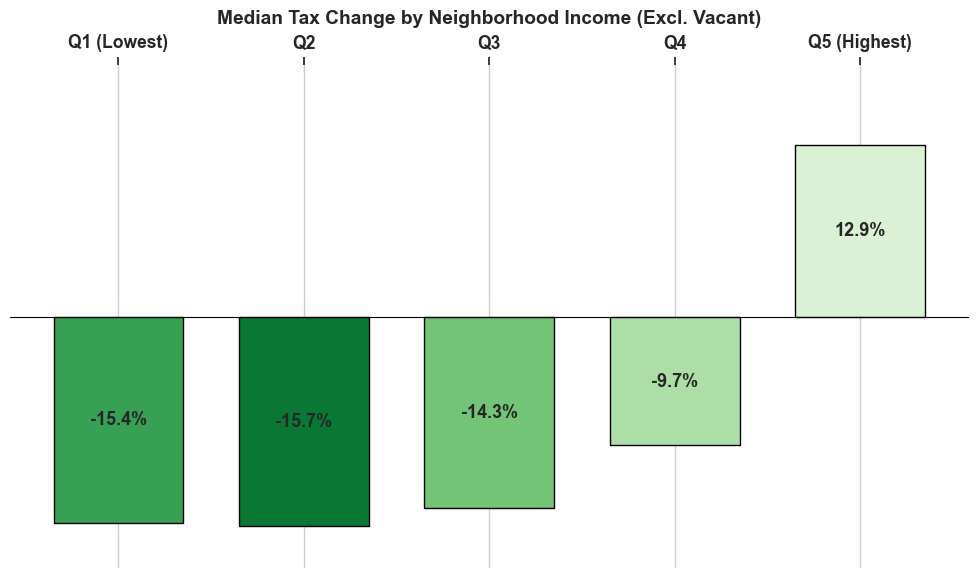

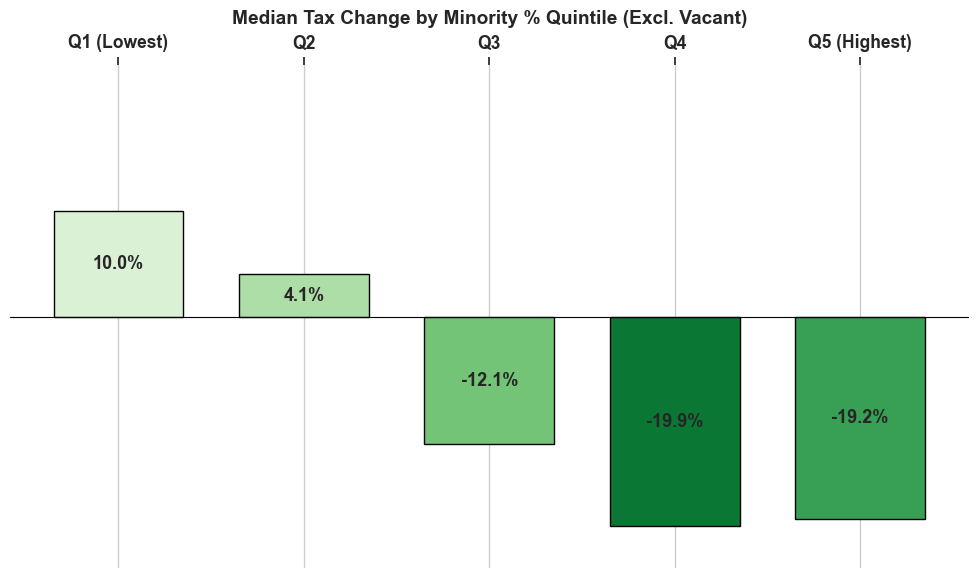

In [66]:
# Inverted bar charts: median tax change by quintile (excluding vacant land)
sns.set_theme(style='whitegrid', font_scale=1.15)

# Income quintiles
fig, ax = plt.subplots(figsize=(10, 6))
vals = non_vacant_income_quintile_summary['median_tax_change_pct']
labels = non_vacant_income_quintile_summary['median_income_quintile']
colors = sns.color_palette('Greens', n_colors=len(vals))
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]

bars = ax.bar(labels, vals, color=color_map, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Median Tax Change by Neighborhood Income (Excl. Vacant)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars, vals):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin = max(abs(vals.min()), abs(vals.max())) * 1.2
ax.set_ylim(-margin, margin)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Minority quintiles
fig, ax = plt.subplots(figsize=(10, 6))
vals2 = non_vacant_minority_quintile_summary['median_tax_change_pct']
labels2 = non_vacant_minority_quintile_summary['minority_pct_quintile']
colors2 = sns.color_palette('Greens', n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]

bars2 = ax.bar(labels2, vals2, color=color_map2, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Median Tax Change by Minority % Quintile (Excl. Vacant)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars2, vals2):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin2 = max(abs(vals2.min()), abs(vals2.max())) * 1.2
ax.set_ylim(-margin2, margin2)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Single family parcels: 57,322


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and wil

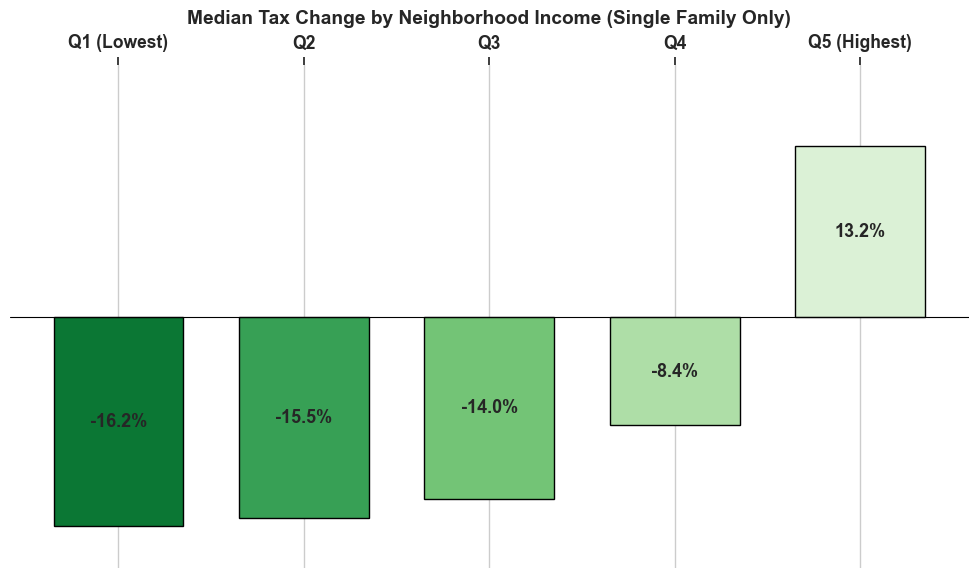

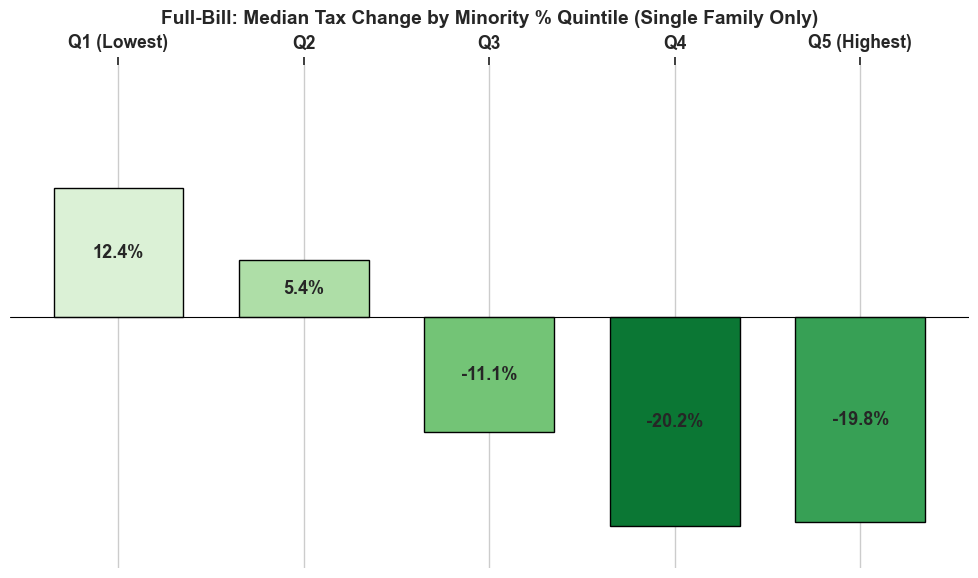

In [67]:
# Inverted bar charts: single family residential only
sfr = df[(df['PROPERTY_CATEGORY'] == 'Single Family Residential') & (df['median_income'] > 0)].copy()
print(f'Single family parcels: {len(sfr):,}')

sfr_income_quintile = create_quintile_summary(sfr, 'median_income', 'median_income')
sfr_minority_quintile = create_quintile_summary(sfr, 'minority_pct', 'minority_pct')

sns.set_theme(style='whitegrid', font_scale=1.15)

# Income quintiles - single family
fig, ax = plt.subplots(figsize=(10, 6))
vals = sfr_income_quintile['median_tax_change_pct']
labels = sfr_income_quintile['median_income_quintile']
colors = sns.color_palette('Greens', n_colors=len(vals))
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]
bars = ax.bar(labels, vals, color=color_map, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Median Tax Change by Neighborhood Income (Single Family Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars, vals):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin = max(abs(vals.min()), abs(vals.max())) * 1.2
ax.set_ylim(-margin, margin)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Minority quintiles - single family
fig, ax = plt.subplots(figsize=(10, 6))
vals2 = sfr_minority_quintile['median_tax_change_pct']
labels2 = sfr_minority_quintile['minority_pct_quintile']
colors2 = sns.color_palette('Greens', n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]
bars2 = ax.bar(labels2, vals2, color=color_map2, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Minority % Quintile (Single Family Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars2, vals2):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin2 = max(abs(vals2.min()), abs(vals2.max())) * 1.2
ax.set_ylim(-margin2, margin2)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Multifamily parcels: 7,378


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and wil

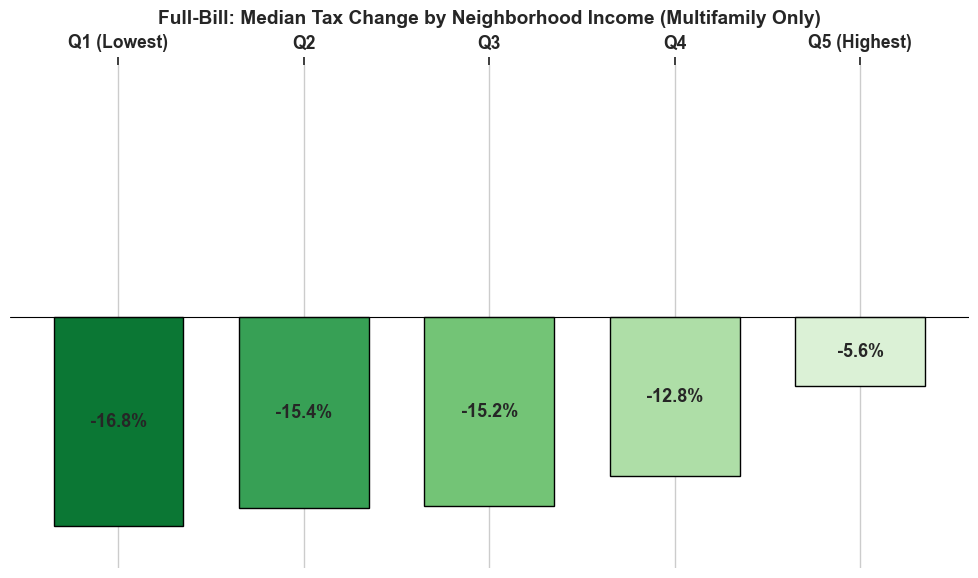

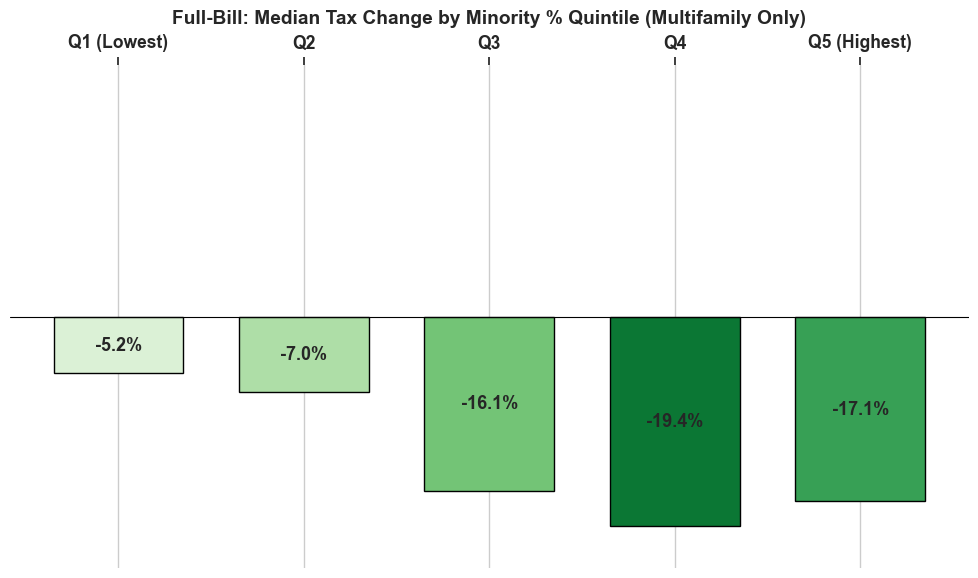

In [68]:
# Inverted bar charts: multifamily residential only
mfr = df[(df['PROPERTY_CATEGORY'].isin(['Small Multi-Family (2-4 units)', 'Large Multi-Family (5+ units)'])) & (df['median_income'] > 0)].copy()
print(f'Multifamily parcels: {len(mfr):,}')

mfr_income_quintile = create_quintile_summary(mfr, 'median_income', 'median_income')
mfr_minority_quintile = create_quintile_summary(mfr, 'minority_pct', 'minority_pct')

sns.set_theme(style='whitegrid', font_scale=1.15)

# Income quintiles - multifamily
fig, ax = plt.subplots(figsize=(10, 6))
vals = mfr_income_quintile['median_tax_change_pct']
labels = mfr_income_quintile['median_income_quintile']
colors = sns.color_palette('Greens', n_colors=len(vals))
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]
bars = ax.bar(labels, vals, color=color_map, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Neighborhood Income (Multifamily Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars, vals):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin = max(abs(vals.min()), abs(vals.max())) * 1.2
ax.set_ylim(-margin, margin)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Minority quintiles - multifamily
fig, ax = plt.subplots(figsize=(10, 6))
vals2 = mfr_minority_quintile['median_tax_change_pct']
labels2 = mfr_minority_quintile['minority_pct_quintile']
colors2 = sns.color_palette('Greens', n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]
bars2 = ax.bar(labels2, vals2, color=color_map2, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Minority % Quintile (Multifamily Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars2, vals2):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin2 = max(abs(vals2.min()), abs(vals2.max())) * 1.2
ax.set_ylim(-margin2, margin2)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Residential parcels: 64,700


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_23332/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and wil

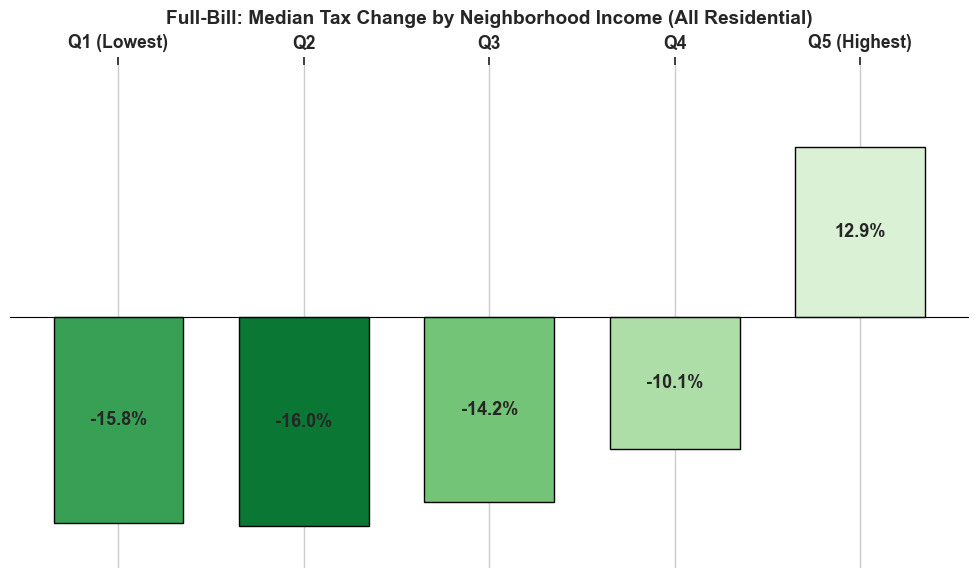

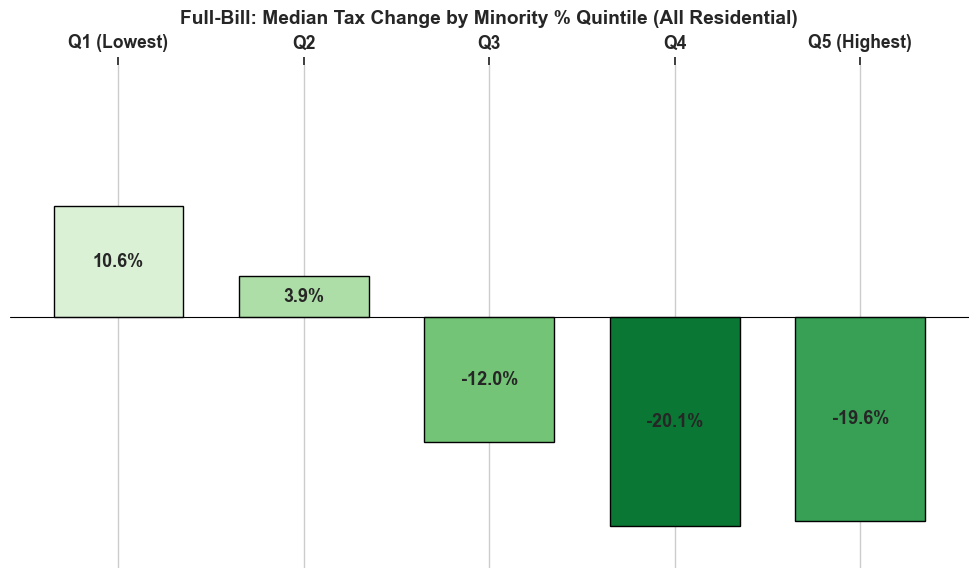

In [69]:
# Inverted bar charts: all residential (SFR + multifamily)
smfr = df[(df['PROPERTY_CATEGORY'].isin(['Single Family Residential','Small Multi-Family (2-4 units)', 'Large Multi-Family (5+ units)'])) & (df['median_income'] > 0)].copy()
print(f'Residential parcels: {len(smfr):,}')

smfr_income_quintile = create_quintile_summary(smfr, 'median_income', 'median_income')
smfr_minority_quintile = create_quintile_summary(smfr, 'minority_pct', 'minority_pct')

sns.set_theme(style='whitegrid', font_scale=1.15)

# Income quintiles - all residential
fig, ax = plt.subplots(figsize=(10, 6))
vals = smfr_income_quintile['median_tax_change_pct']
labels = smfr_income_quintile['median_income_quintile']
colors = sns.color_palette('Greens', n_colors=len(vals))
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]
bars = ax.bar(labels, vals, color=color_map, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Neighborhood Income (All Residential)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars, vals):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin = max(abs(vals.min()), abs(vals.max())) * 1.2
ax.set_ylim(-margin, margin)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Minority quintiles - all residential
fig, ax = plt.subplots(figsize=(10, 6))
vals2 = smfr_minority_quintile['median_tax_change_pct']
labels2 = smfr_minority_quintile['minority_pct_quintile']
colors2 = sns.color_palette('Greens', n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]
bars2 = ax.bar(labels2, vals2, color=color_map2, edgecolor='black', width=0.7)
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Minority % Quintile (All Residential)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars2, vals2):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
margin2 = max(abs(vals2.min()), abs(vals2.max())) * 1.2
ax.set_ylim(-margin2, margin2)
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Step 9: The Incentive Effect — Full Bill

Under HF 1342, the **entire tax bill** is reallocated. This means the rate advantage for improvements is much larger than the city-only analysis:

- Current system: every \$1 of new improvement TC is taxed at the **full combined rate** (~1.55)
- Split-rate system: every \$1 of new improvement TC is taxed at the **improvement millage** (~0.94)

The rate advantage per dollar of improvement is ~0.61 under the full bill, compared to ~0.21 in the city-only model. This means every dollar of investment saves roughly 3× as much in taxes.

In [70]:
# Effective full tax rate from our working set
full_tax_rate = current_revenue / st_paul_city['TaxCapacity'].sum()
residential_class_rate = 0.01  # MN class rate for residential homestead under $500K

print(f'Full effective tax rate: {full_tax_rate:.4f} per $ of TC')
print(f'Improvement millage:    {tc_imp_millage:.4f} per $1000 of TC = {tc_imp_millage/1000:.6f} per $ of TC')
print(f'Rate advantage:         {full_tax_rate - tc_imp_millage/1000:.4f} per $ of TC')
print(f'\nFor comparison, city-only NTC rate is {OFFICIAL_CITY_TAX_RATE:.4f}')
print(f'Full bill captures {full_tax_rate / OFFICIAL_CITY_TAX_RATE:.1f}x more revenue per $ of TC')

Full effective tax rate: 1.5472 per $ of TC
Improvement millage:    929.0008 per $1000 of TC = 0.929001 per $ of TC
Rate advantage:         0.6182 per $ of TC

For comparison, city-only NTC rate is 0.5270
Full bill captures 2.9x more revenue per $ of TC


1056 EVERETT CT
  Current full tax: $5,696
  Split-rate tax:   $7,807 (+$2,111)
  Crossover at $341,519 in improvements


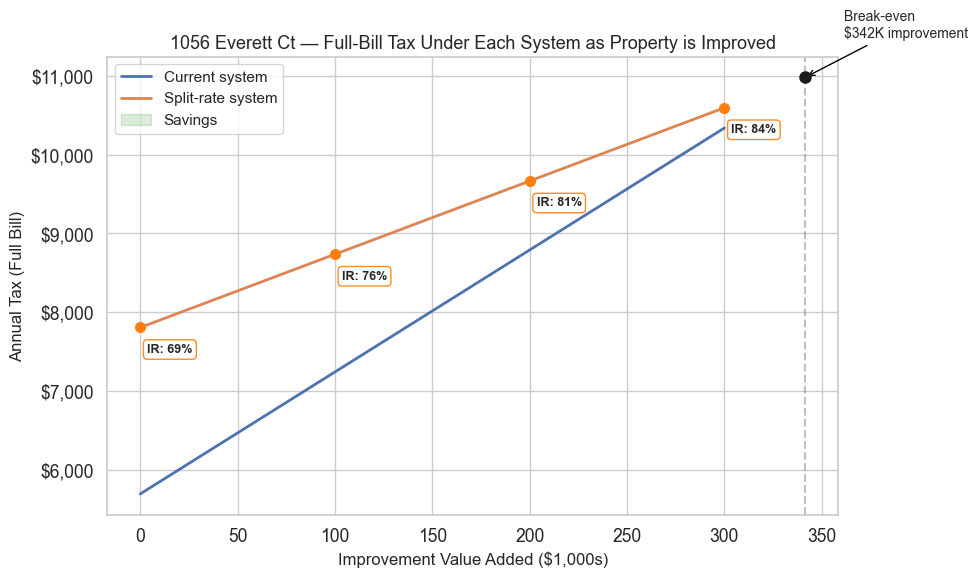

In [71]:
# 1056 Everett Ct: how improvement changes the tax comparison (full bill)
prop = st_paul_city[st_paul_city['SiteAddress'].str.contains('1056 EVERETT', case=False, na=False)].iloc[0]

current_tax_base = prop['current_tax']
split_tax_base = prop['new_tax_tc']
emv_bldg = prop['EMVBuilding1']
emv_total = prop['EMVTotal1']

reno_values = np.arange(0, 300_001, 1_000)

# Full bill: marginal rate is full_tax_rate per $ of TC
current_system_tax = current_tax_base + full_tax_rate * reno_values * residential_class_rate
split_rate_tax = split_tax_base + (tc_imp_millage / 1000) * reno_values * residential_class_rate

# Crossover
gap = split_tax_base - current_tax_base
rate_advantage = full_tax_rate - tc_imp_millage / 1000
crossover = gap / (rate_advantage * residential_class_rate)
crossover_tax = current_tax_base + full_tax_rate * crossover * residential_class_rate

print(f'1056 EVERETT CT')
print(f'  Current full tax: ${current_tax_base:,.0f}')
print(f'  Split-rate tax:   ${split_tax_base:,.0f} (+${gap:,.0f})')
print(f'  Crossover at ${crossover:,.0f} in improvements')

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(reno_values / 1000, current_system_tax, label='Current system', linewidth=2)
ax.plot(reno_values / 1000, split_rate_tax, label='Split-rate system', linewidth=2)

mask = reno_values >= crossover
ax.fill_between(reno_values[mask] / 1000, split_rate_tax[mask], current_system_tax[mask],
                alpha=0.15, color='green', label='Savings')

ax.axvline(x=crossover / 1000, color='gray', linestyle='--', alpha=0.5)
ax.plot(crossover / 1000, crossover_tax, 'ko', markersize=8, zorder=5)
ax.annotate(f'Break-even\n${crossover/1000:.0f}K improvement',
            xy=(crossover / 1000, crossover_tax),
            xytext=(crossover / 1000 + 20, crossover_tax + 500),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

for reno in [0, 100_000, 200_000, 300_000]:
    ir = (emv_bldg + reno) / (emv_total + reno)
    idx = int(reno / 1000)
    tax_at_point = split_rate_tax[idx]
    ax.plot(reno / 1000, tax_at_point, 'o', color='tab:orange', markersize=7, zorder=5)
    ax.annotate(f'IR: {ir*100:.0f}%',
                xy=(reno / 1000, tax_at_point),
                xytext=(5, -18), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='tab:orange', alpha=0.9))

ax.set_xlabel('Improvement Value Added ($1,000s)', fontsize=12)
ax.set_ylabel('Annual Tax (Full Bill)', fontsize=12)
ax.set_title('1056 Everett Ct — Full-Bill Tax Under Each System as Property is Improved', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

719 Hague Ave starts with a **tax cut** under the split-rate — the lines are flipped. Because improvements are taxed at the lower rate, every dollar of investment widens the savings further. With the full bill, the savings are even larger.

719 HAGUE AVE
  Current full tax: $8,312
  Split-rate tax:   $7,337 (-$976)
  Savings grow from $976/year to $2,830/year ($300K improvement)


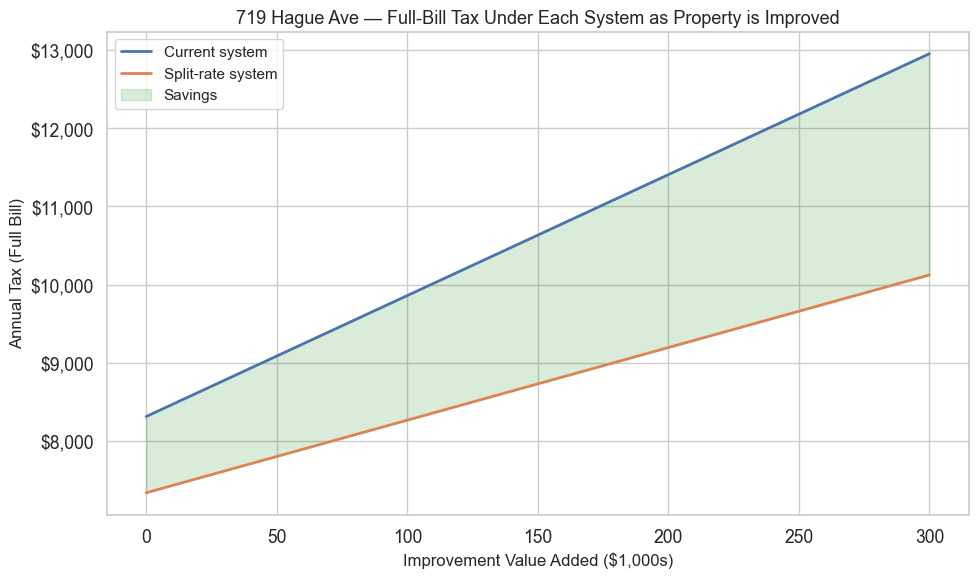

In [72]:
# 719 Hague Ave: split-rate already cheaper, improvement widens the gap (full bill)
prop = st_paul_city[st_paul_city['SiteAddress'].str.contains('719 HAGUE', case=False, na=False)].iloc[0]

current_tax_base = prop['current_tax']
split_tax_base = prop['new_tax_tc']

reno_values = np.arange(0, 300_001, 1_000)

current_system_tax = current_tax_base + full_tax_rate * reno_values * residential_class_rate
split_rate_tax = split_tax_base + (tc_imp_millage / 1000) * reno_values * residential_class_rate

savings_at_0 = current_tax_base - split_tax_base
savings_at_300k = current_system_tax[-1] - split_rate_tax[-1]

print(f'719 HAGUE AVE')
print(f'  Current full tax: ${current_tax_base:,.0f}')
print(f'  Split-rate tax:   ${split_tax_base:,.0f} (-${savings_at_0:,.0f})')
print(f'  Savings grow from ${savings_at_0:,.0f}/year to ${savings_at_300k:,.0f}/year ($300K improvement)')

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(reno_values / 1000, current_system_tax, label='Current system', linewidth=2)
ax.plot(reno_values / 1000, split_rate_tax, label='Split-rate system', linewidth=2)

ax.fill_between(reno_values / 1000, split_rate_tax, current_system_tax, alpha=0.15, color='green', label='Savings')

ax.set_xlabel('Improvement Value Added ($1,000s)', fontsize=12)
ax.set_ylabel('Annual Tax (Full Bill)', fontsize=12)
ax.set_title('719 Hague Ave — Full-Bill Tax Under Each System as Property is Improved', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [95]:
# Save modeled data for use in st_paul_policy_analysis.ipynb
st_paul_city.to_parquet(os.path.join(save_dir, 'st_paul_city_modeled.gpq'))
st_paul_gdf.to_parquet(os.path.join(save_dir, 'st_paul_gdf.gpq'))
print(f'Saved {len(st_paul_city):,} city-taxable parcels and {len(st_paul_gdf):,} total parcels')


Saved 72,389 city-taxable parcels and 83,399 total parcels
